In [38]:
import sys, os, pickle
from datetime import datetime
import numpy as np
import pandas as pd
from tqdm import tqdm
from joblib import Parallel, delayed

SRC_PATH = '/content/drive/MyDrive/ellis-attribution/src'
sys.path.insert(0, SRC_PATH)

from src.attribution import (
    compute_pn,
    run_thermo_ml,
    run_dyn_adj_local,
    run_dml_dyn_adj_local
)
from src.analogues import (
    run_analogues,
    run_analogues_local,
    run_analogues_local_lasso,
    run_analogues_causal_knn
)
from src.data_utils import extract_local_slp

from matplotlib import pyplot as plt
from src.sparse_unconditional_analogues import KNNAnalogueAttributor

from src.visualization import *

from src.deep_attributtor_v2 import DeepCausalMediation, train_causal_model, estimate_pn

import torch
import torch.nn.functional as F


In [39]:
# ================================================================
#  CONFIG  —  edit here
# ================================================================
path_extracted = '/home/homer/Documents/Research/Data/attribution_evaluation_data/extracted/'
DATA_PATH    = path_extracted + 'extracted_tasmax_nmem10_start2004_p99.9.pkl'

RESULTS_DIR = 'results'

# PN estimators to run for every method
# Options: 'empirical', 'gaussian', 'gev'  (can select multiple)
STAT_METHODS = ['gaussian']

# Time window around each event
WINDOW_BEFORE = 72   # months
WINDOW_AFTER  = 12   # months

N_JOBS = 2#os.cpu_count()
# ================================================================

In [40]:
with open(DATA_PATH, 'rb') as fh:
    data = pickle.load(fh)

In [41]:
def build_ctx(res, e_idx, is_factual):
    """Assemble the context dict passed to every attribution method."""
    tas_run = res['f_tas'] if is_factual else res['c_tas']
    slp_run = res['f_slp'] if is_factual else res['c_slp']
    idx_run = res['idx_f'] if is_factual else res['idx_c']
    t_obs   = idx_run[e_idx]
    t0      = max(0, t_obs - WINDOW_BEFORE)
    t1      = min(tas_run.shape[0], t_obs + WINDOW_AFTER)
    return {
        'tas':   tas_run[:, e_idx],
        'gmt':   res['gmt4_f'] if is_factual else res['gmt4_c'],
        'slp':   slp_run,
        'slp_lat': res['slp_lat'],
        'slp_lon': res['slp_lon'],
        'ev_lat':  res['f_location'][e_idx, 0],
        'ev_lon':  res['f_location'][e_idx, 1],
        'val':     res['f_tas_vals'][e_idx] if is_factual else res['c_tas_vals'][e_idx],
        'range':   (t0, t1),
        't_obs':   t_obs,
        'idx': idx_run
    }

In [89]:
member, e_idx = 0, 1
factual = False
data_event = data[member]
obs_data = build_ctx(data_event, e_idx=e_idx, is_factual=factual)

In [90]:
def extract_local_slp(slp_3d, slp_lat, slp_lon, ev_lat, ev_lon, half_width_deg):
    lat_min = np.clip(ev_lat - half_width_deg, slp_lat.min(), slp_lat.max())
    lat_max = np.clip(ev_lat + half_width_deg, slp_lat.min(), slp_lat.max())
    lon_min = np.clip(ev_lon - half_width_deg, slp_lon.min(), slp_lon.max())
    lon_max = np.clip(ev_lon + half_width_deg, slp_lon.min(), slp_lon.max())

    lat_idx = np.where((slp_lat >= lat_min) & (slp_lat <= lat_max))[0]
    lon_idx = np.where((slp_lon >= lon_min) & (slp_lon <= lon_max))[0]

    local = slp_3d[:, lat_idx[:, None], lon_idx[None, :]]   # (T, n_lat_b, n_lon_b)
    return np.nan_to_num(local)

In [91]:
X = obs_data['gmt']
Y = obs_data['tas']
Z = extract_local_slp(
    obs_data['slp'], obs_data['slp_lat'], obs_data['slp_lon'], 
    obs_data['ev_lat'], obs_data['ev_lon'], half_width_deg=10
)

X = (X - X.mean()) / X.std()
Y = (Y - Y.mean()) / Y.std()
Z = (Z - Z.mean(axis=0)) / Z.std(axis=0)

In [45]:
dcm = DeepCausalMediation(k_clusters=5, latent_dim=32, input_channels=1, spatial_dim=Z.shape[1:])
dcm, history = train_causal_model(X, Y, Z, dcm,epochs=200, batch_size=32, lr=1e-3, patience=15, val_split=0.2, tau_start=1.0, tau_min=0.1, lambda_kl_start=0.0, lambda_kl_max=1.0, lambda_kl_warmup=0.3, grad_clip=1.0, seed=42, num_workers=0)

In [46]:
x_c = X[0]
x_f = X[obs_data['idx'][e_idx]]
y_th = Y[obs_data['idx'][e_idx]]

In [47]:
p_c, p_f, pn = estimate_pn(dcm, x_c, x_f, y_th)
pn

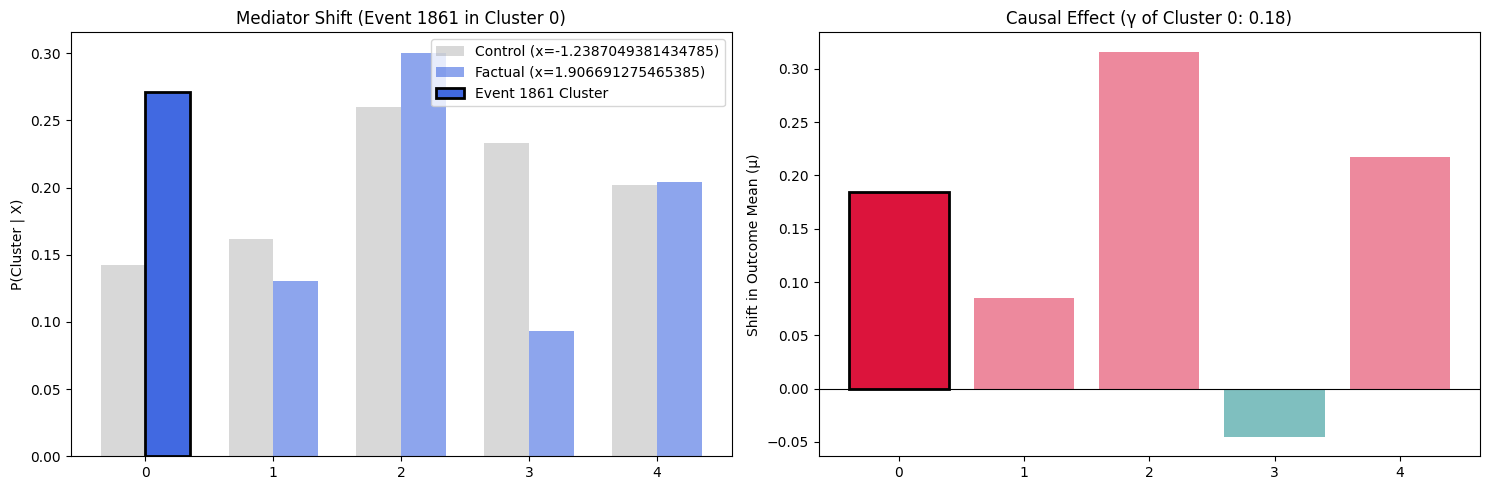

In [48]:
@torch.no_grad()
def plot_causal_breakdown_with_event(model, x_c, x_f, event_idx, Z_dataset):
    """
    Plots global causal shift and highlights the cluster assignment 
    for a specific event from the dataset.
    """
    model.eval()
    device = next(model.parameters()).device
    
    # --- 1. Global Data Acquisition (X -> Z and Z -> Y) ---
    x_t = torch.tensor([[x_c], [x_f]], dtype=torch.float32).to(device)
    probs = F.softmax(model.mediator_model(x_t), dim=-1).cpu().numpy()
    p_c, p_f = probs[0], probs[1]
    
    gammas = model.mediated_head(model.cluster_embeddings.weight).squeeze().cpu().numpy()
    indices = np.arange(model.K)
    
    # --- 2. Specific Event Processing (Z_idx -> Cluster) ---
    # Get the image for the specific event
    z_event = torch.tensor(Z_dataset[event_idx], dtype=torch.float32).to(device)
    if z_event.ndim == 3: z_event = z_event.unsqueeze(0) # Add batch and channel if needed
    if z_event.ndim == 2: z_event = z_event.unsqueeze(0).unsqueeze(0)

    # Pass through encoder to get cluster distribution q(k|z)
    _, q_k_z = model.encode_z(z_event, tau=1.0, hard=True) # hard=True gives 1-hot
    event_cluster = torch.argmax(q_k_z).item()
    
    # --- 3. Plotting ---
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # Plot 1: The Shift (X -> Z)
    width = 0.35
    ax1.bar(indices - width/2, p_c, width, label=f'Control (x={x_c})', color='gray', alpha=0.3)
    ax1.bar(indices + width/2, p_f, width, label=f'Factual (x={x_f})', color='royalblue', alpha=0.6)
    
    # Highlight the cluster the event belongs to
    ax1.bar(event_cluster + width/2, p_f[event_cluster], width, 
            edgecolor='black', linewidth=2, color='royalblue', label=f'Event {event_idx} Cluster')
    
    ax1.set_title(f"Mediator Shift (Event {event_idx} in Cluster {event_cluster})")
    ax1.set_ylabel("P(Cluster | X)")
    ax1.set_xticks(indices)
    ax1.legend()

    # Plot 2: The Impact (Z -> Y)
    colors = ['crimson' if g > 0 else 'teal' for g in gammas]
    bars = ax2.bar(indices, gammas, color=colors, alpha=0.5)
    
    # Highlight the specific cluster's causal power
    bars[event_cluster].set_alpha(1.0)
    bars[event_cluster].set_edgecolor('black')
    bars[event_cluster].set_linewidth(2)
    
    ax2.axhline(0, color='black', linewidth=0.8)
    ax2.set_title(f"Causal Effect (γ of Cluster {event_cluster}: {gammas[event_cluster]:.2f})")
    ax2.set_ylabel("Shift in Outcome Mean (μ)")
    ax2.set_xticks(indices)
    
    plt.tight_layout()
    plt.show()
    
    return event_cluster

plot_causal_breakdown_with_event(dcm, x_c, x_f, obs_data['idx'][e_idx], Z)

In [49]:
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from scipy.stats import norm

@torch.no_grad()
def plot_mediated_vs_total_shift(model, x_c, x_f, threshold=None):
    model.eval()
    device = next(model.parameters()).device
    
    # 1. Extract Model Parameters
    x_t = torch.tensor([[x_c], [x_f]], dtype=torch.float32).to(device)
    
    # Direct effects (deltas) and standard deviations (sigmas)
    deltas = model.direct_head(x_t).cpu().numpy().squeeze() # [delta_c, delta_f]
    sigmas = torch.exp(0.5 * model.logvar_head(x_t)).cpu().numpy().squeeze() # [sigma_c, sigma_f]
    
    # Mediator cluster probabilities P(Bk | X)
    probs = F.softmax(model.mediator_model(x_t), dim=-1).cpu().numpy()
    p_k_c, p_k_f = probs[0], probs[1]
    
    # Cluster specific shifts (gammas)
    gammas = model.mediated_head(model.cluster_embeddings.weight).squeeze().cpu().numpy()
    
    # 2. Define the PDF Mixture Function
    def get_mixture_pdf(x_grid, delta, sigma, p_k):
        pdf = np.zeros_like(x_grid)
        for k in range(model.K):
            mu_k = delta + gammas[k]
            pdf += p_k[k] * norm.pdf(x_grid, mu_k, sigma)
        return pdf

    # Define range for plotting
    all_means = np.concatenate([deltas[0] + gammas, deltas[1] + gammas])
    x_grid = np.linspace(np.min(all_means) - 3*np.max(sigmas), 
                         np.max(all_means) + 3*np.max(sigmas), 500)
    
    # 3. Calculate the Three Distributions
    # A: Baseline (Control)
    pdf_baseline = get_mixture_pdf(x_grid, deltas[0], sigmas[0], p_k_c)
    
    # B: Mediated Shift (Change P_k to factual, keep delta at control)
    # This shows what happens if ONLY the mediator Z changes
    pdf_mediated = get_mixture_pdf(x_grid, deltas[0], sigmas[0], p_k_f)
    
    # C: Total Effect (Change both P_k and delta to factual)
    pdf_total = get_mixture_pdf(x_grid, deltas[1], sigmas[1], p_k_f)
    
    # 4. Plotting
    plt.figure(figsize=(12, 7))
    
    plt.plot(x_grid, pdf_baseline, label=f'Control: P(Y|do(x_c))', 
             color='gray', lw=2.5, alpha=0.6)
    
    plt.plot(x_grid, pdf_mediated, label=f'Mediated Effect: P(Y_{{Z(x_f)}} | x_c)', 
             color='forestgreen', lw=2, linestyle='--')
    
    plt.plot(x_grid, pdf_total, label=f'Total Effect: P(Y|do(x_f))', 
             color='royalblue', lw=2.5)
    
    # Visualize the Threshold and Risk Areas
    if threshold is not None:
        plt.axvline(threshold, color='crimson', linestyle=':', label='Event Threshold ($y_{th}$)')
        plt.fill_between(x_grid, pdf_total, where=(x_grid > threshold), 
                         color='royalblue', alpha=0.1)
        plt.fill_between(x_grid, pdf_baseline, where=(x_grid > threshold), 
                         color='gray', alpha=0.1)

    plt.title(f"Causal Distribution Shift: Mediation vs. Total Effect\n(X={x_c} to X={x_f})", fontsize=14)
    plt.xlabel("Outcome Value (Y)", fontsize=12)
    plt.ylabel("Probability Density", fontsize=12)
    plt.legend(frameon=True, facecolor='white', framealpha=1)
    plt.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()

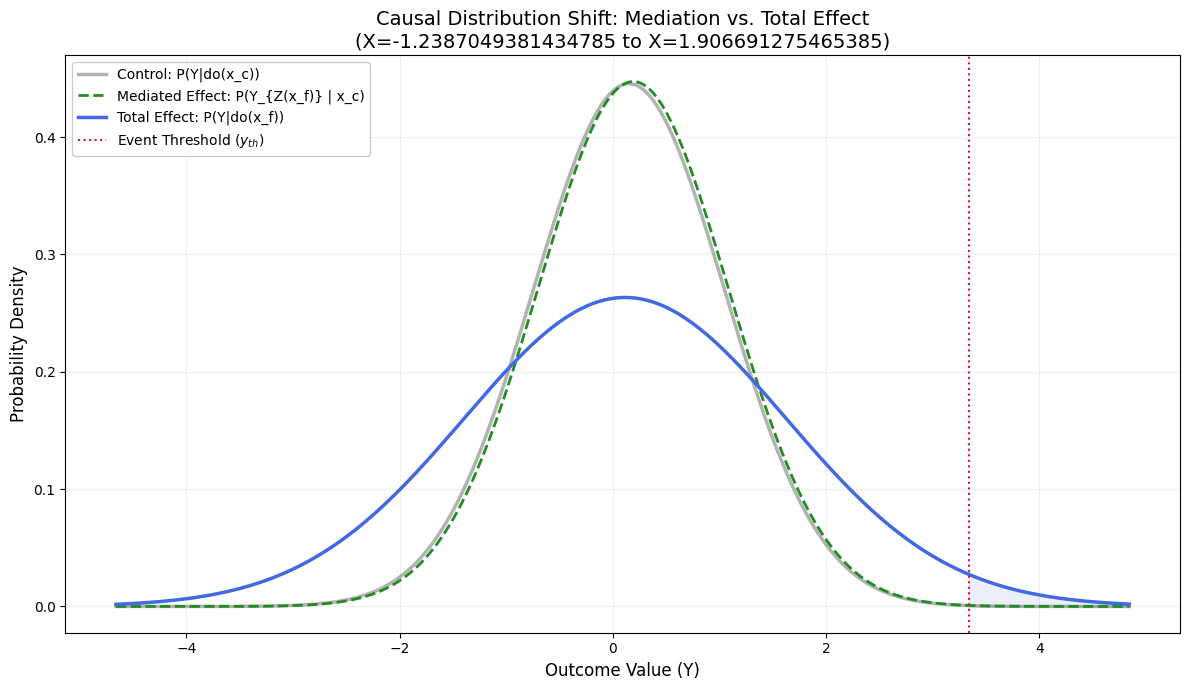

In [50]:
plot_mediated_vs_total_shift(dcm, x_c=x_c, x_f=x_f, threshold=y_th)
# plt.vlines(y_th, ymin=0, ymax=plt.gca().get_ylim()[1], color='red', linestyle='--', label=f'Observed Y={y_th:.2f}')

In [100]:
from sklearn.decomposition import PCA
from sklearn.linear_model import RidgeCV, LinearRegression


Z = Z.reshape(Z.shape[0], -1) # flatten spatial dimensions
Zpcs = PCA(n_components=100).fit_transform(Z)
ridge = LinearRegression().fit(Zpcs, Y)
preds = ridge.predict(Zpcs)                    

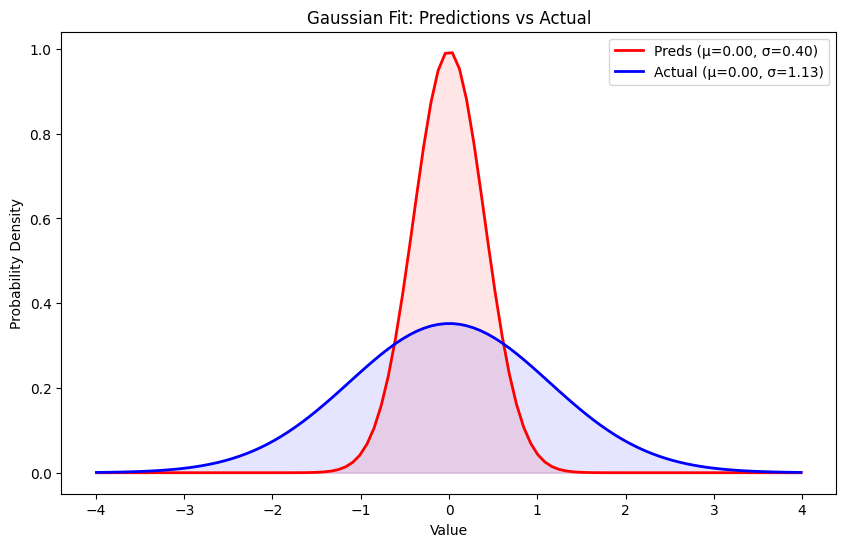

In [101]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# 1. Extract the specific data slice
t0, t1 = obs_data['range']
y_subset = Y[t0:t1]

# 2. Fit the distributions (calculate mean and std dev)
mu_preds, std_preds = norm.fit(preds)
mu_y, std_y = norm.fit(y_subset)

# 3. Create an x-axis range for the plot
xmin = min(preds.min(), y_subset.min())
xmax = max(preds.max(), y_subset.max())
x = np.linspace(xmin, xmax, 100)

# 4. Generate the PDF curves
p_preds = norm.pdf(x, mu_preds, std_preds)
p_y = norm.pdf(x, mu_y, std_y)

# 5. Plotting
plt.figure(figsize=(10, 6))
plt.plot(x, p_preds, 'r-', lw=2, label=f'Preds (μ={mu_preds:.2f}, σ={std_preds:.2f})')
plt.plot(x, p_y, 'b-', lw=2, label=f'Actual (μ={mu_y:.2f}, σ={std_y:.2f})')
plt.fill_between(x, p_preds, color='red', alpha=0.1)
plt.fill_between(x, p_y, color='blue', alpha=0.1)

plt.title('Gaussian Fit: Predictions vs Actual')
plt.xlabel('Value')
plt.ylabel('Probability Density')
plt.legend()
plt.show()

In [87]:

# Calculate p_c (Counterfactual) from the prediction Gaussian
p_c = norm.sf(y_th, loc=mu_preds, scale=std_preds)

# Calculate p_f (Factual) from the actual data Gaussian
p_f = norm.sf(y_th, loc=mu_y, scale=std_y)

# Compute RR and PN
if p_c > 0:
    rr = p_f / p_c
    pn = max(0, 1 - 1/rr)
else:
    pn = 0.0 # Handle division by zero if p_c is negligible

print(f"Relative Risk: {rr:.2f}")
print(f"Probability of Necessity: {pn:.2%}")

Relative Risk: 4600404248904878961130688795600932295833372562566694731784266894970799211516475308992237812367015779176789000958474921746677255117749721102960069512541986337565161451379588211151933848690050944808279902659884999952889850364110284365720762701979116355102254876407930372102024034693152768.00
Probability of Necessity: 0.00%
